# Netflix and Pokémon Data Visualization using Pandas and Matplotlib

## Aim

The aim of this notebook is to perform data preprocessing and create different types of visualizations using the **Pandas** and **Matplotlib** libraries. The notebook analyzes two datasets: the Netflix Titles dataset and the Pokémon dataset. Various charts are generated to identify trends, distributions, and relationships within the data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the Netflix Dataset

The Netflix dataset is loaded from a CSV file into a Pandas DataFrame for further analysis.

In [2]:
data = pd.read_csv('netflix_titles_duration_minutes.csv')

# Data Cleaning

Missing values are handled before visualization.

- Missing values in the **director**, **cast**, and **country** columns are replaced with **"Unknown"**.
- Missing values in the **duration** column are replaced with the median duration.
- A separate DataFrame containing only movies is created for statistical analysis.

In [3]:
movies = data[data['type'] == 'Movie']

movies['duration'].describe()

data[['director', 'cast', 'country']] = data[['director', 'cast', 'country']].fillna('Unknown')

data['duration'] = data['duration'].fillna(data['duration'].median())

# Line Graph – Netflix Titles Added Per Year

The **date_added** column is converted into datetime format. The year is extracted and used to determine the number of titles added each year.

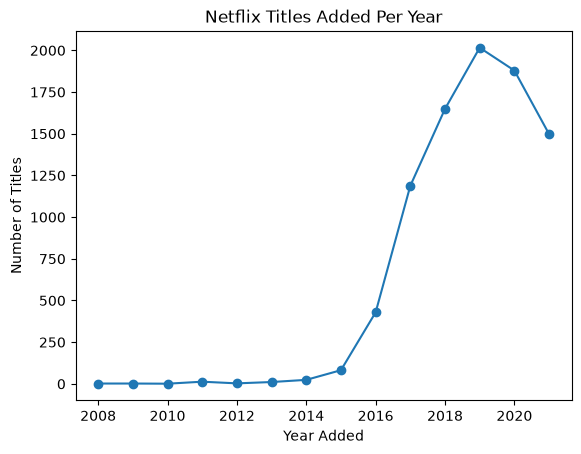

In [4]:
data['date_added'] = pd.to_datetime(data['date_added'].str.strip(), errors='coerce')

data['year_added'] = data['date_added'].dt.year

titles_per_year = data['year_added'].value_counts().sort_index()

titles_per_year.plot(kind='line', marker='o')

plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.title('Netflix Titles Added Per Year')

plt.show()

### Interpretation

The graph shows how Netflix expanded its library over the years by adding more titles annually.

# Bar Graph – Movies vs TV Shows

This graph compares the number of movies and TV shows available on Netflix.

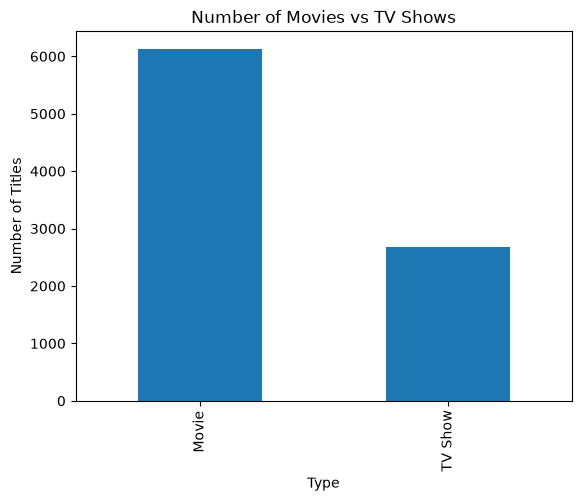

In [5]:
data['type'].value_counts().plot(kind='bar')

plt.xlabel('Type')
plt.ylabel('Number of Titles')
plt.title('Number of Movies vs TV Shows')

plt.show()

### Interpretation

The graph shows that one type of content is more common than the other in the Netflix library.

# Histogram – Duration Distribution

The histogram shows how Netflix title durations are distributed.

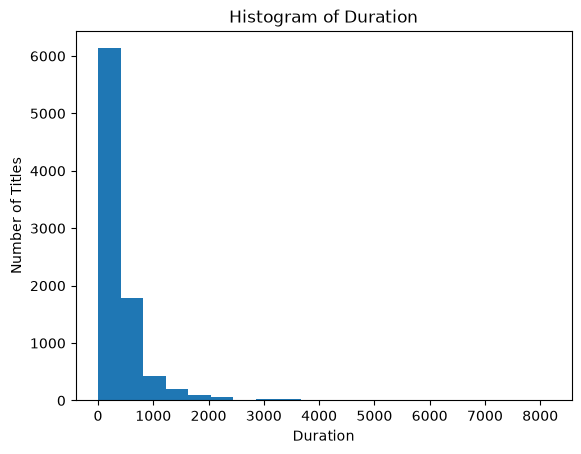

In [6]:
plt.hist(data['duration'].dropna(), bins=20)

plt.xlabel('Duration')
plt.ylabel('Number of Titles')
plt.title('Histogram of Duration')

plt.show()

### Interpretation

Most Netflix titles fall within a particular duration range, while very short and very long titles are less common.

# Bar Graph – Top Content Ratings

This graph displays the most frequently occurring content ratings.

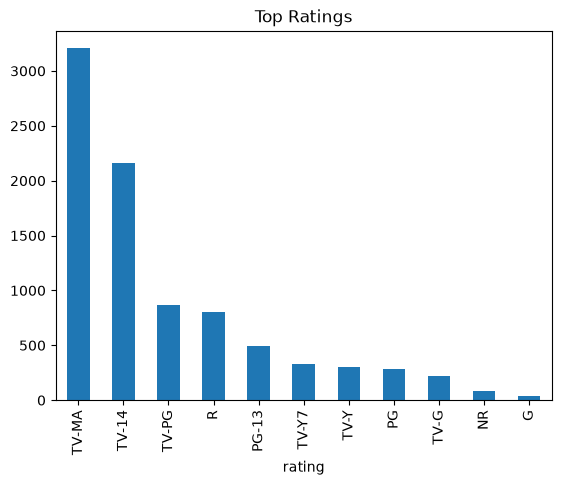

In [7]:
data['rating'].value_counts().head(11).plot(kind='bar')

plt.title('Top Ratings')

plt.show()

### Interpretation

The graph highlights the most common audience ratings assigned to Netflix titles.

# Histogram – Release Year Distribution

This histogram shows the distribution of Netflix titles based on their release year.

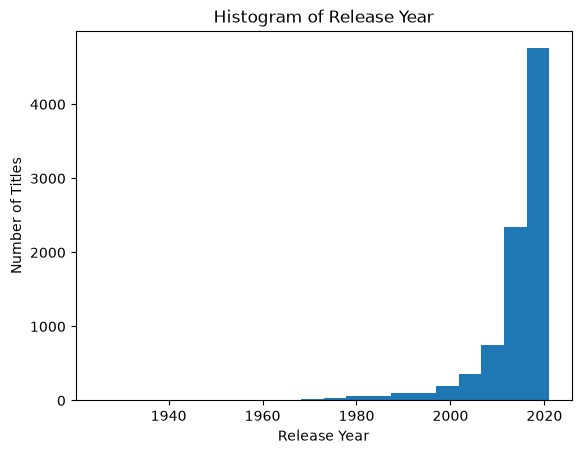

In [8]:
plt.hist(data['release_year'].dropna(), bins=20)

plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.title('Histogram of Release Year')

plt.show()

### Interpretation

Most Netflix titles belong to recent release years, indicating a greater availability of newer content.
# Pie Chart – Movies vs TV Shows

The pie chart illustrates the percentage of movies and TV shows in the Netflix dataset.

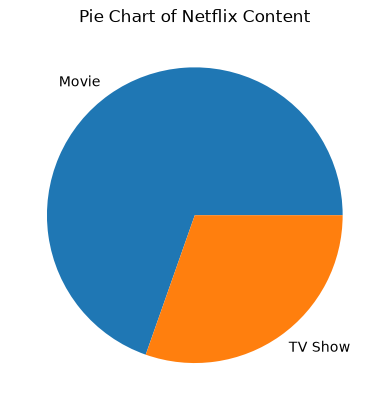

In [9]:
plt.pie(data['type'].value_counts(),
        labels=data['type'].unique())

plt.title('Pie Chart of Netflix Content')

plt.show()

### Interpretation

The pie chart provides a visual comparison of the proportion of movies and TV shows available on Netflix.
# Scatter Plot – Release Year vs Encoded Rating

Since ratings are categorical values, they are converted into numerical values before plotting.

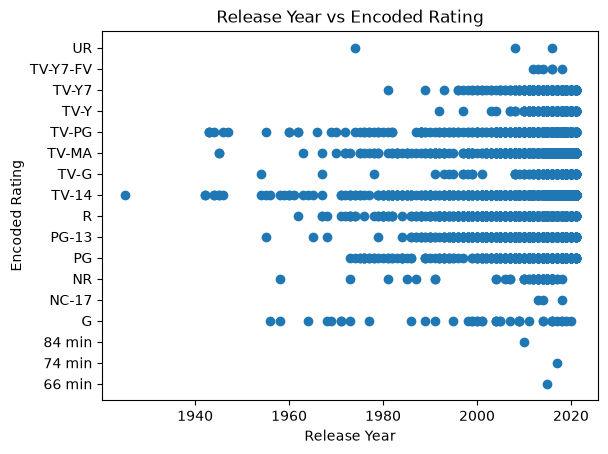

In [10]:
rating_map = {
    rating: index
    for index, rating in enumerate(sorted(data['rating'].dropna().unique()))
}

data['encoded_Rating'] = data['rating'].map(rating_map)

plt.scatter(data['release_year'],
            data['encoded_Rating'])

plt.title("Release Year vs Encoded Rating")
plt.xlabel("Release Year")
plt.ylabel("Encoded Rating")

plt.yticks(list(rating_map.values()),
           list(rating_map.keys()))

plt.show()

### Interpretation

The scatter plot shows the distribution of different content ratings across release years.
# Loading the Pokémon Dataset

The Pokémon dataset is loaded to create additional visualizations.

In [11]:
df = pd.read_csv("All_Pokemon.csv")

# Heatmap – Correlation of Pokémon Statistics

The heatmap shows the correlation between numerical Pokémon attributes.

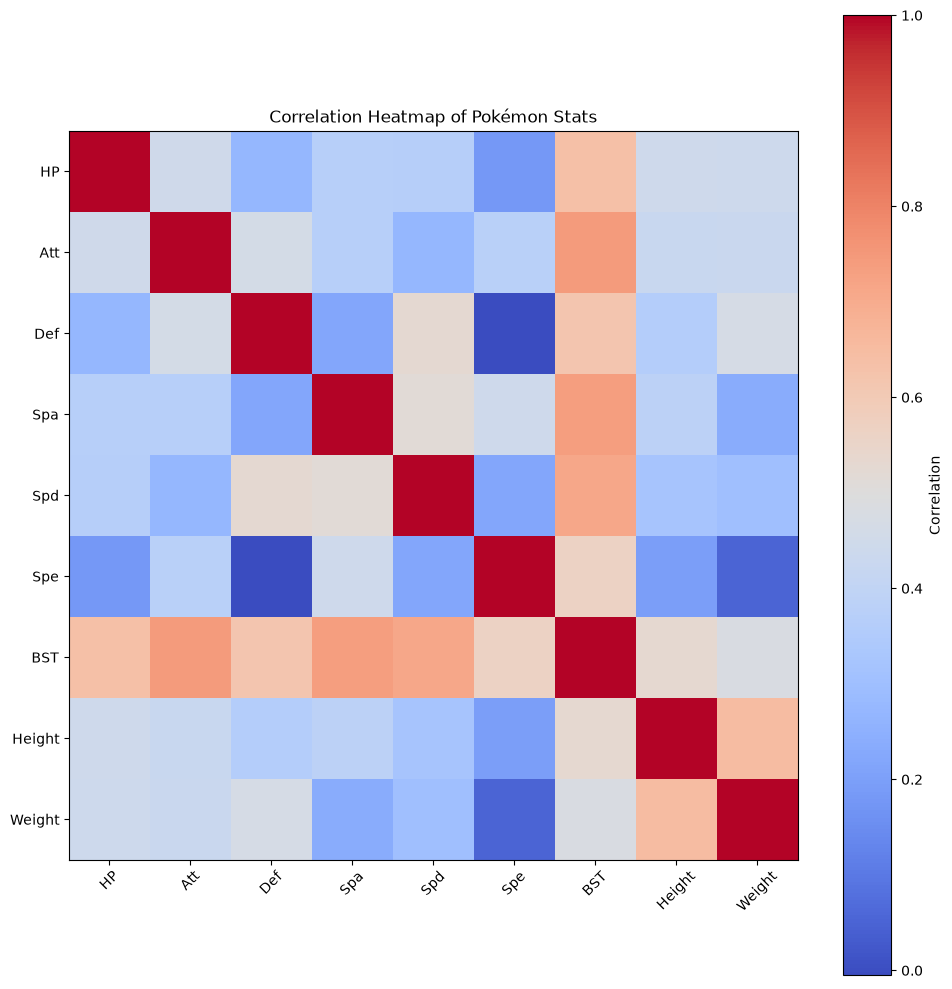

In [12]:
plt.figure(figsize=(10,10))

numeric_cols = ['HP','Att','Def','Spa','Spd','Spe','BST','Height','Weight']

corr = df[numeric_cols].corr()

plt.imshow(corr,
           cmap='coolwarm',
           interpolation='nearest')

plt.colorbar(label='Correlation')

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=45)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Heatmap of Pokémon Stats")

plt.tight_layout()

plt.show()

### Interpretation

The heatmap indicates how strongly Pokémon attributes are related. Darker colors represent stronger positive or negative correlations.
# Pie Chart – Legendary Distribution

This pie chart compares legendary and non-legendary Pokémon.

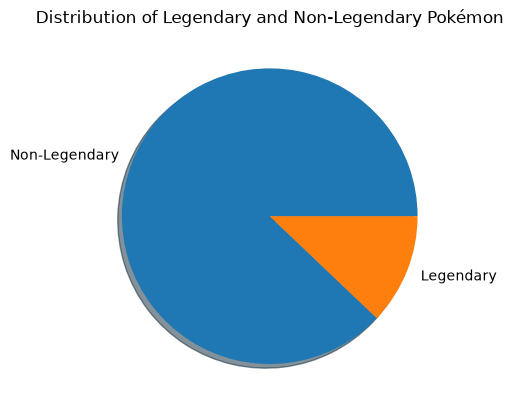

In [13]:
legendary_count = df['Legendary'].value_counts()

plt.pie(
    legendary_count,
    labels=['Non-Legendary', 'Legendary'],
    shadow=True
)

plt.title("Distribution of Legendary and Non-Legendary Pokémon")

plt.show()

### Interpretation

The chart shows that legendary Pokémon make up only a small portion of the overall Pokémon population.

# Horizontal Bar Graph – Pokémon by Primary Type

This graph displays the number of Pokémon belonging to each primary type.

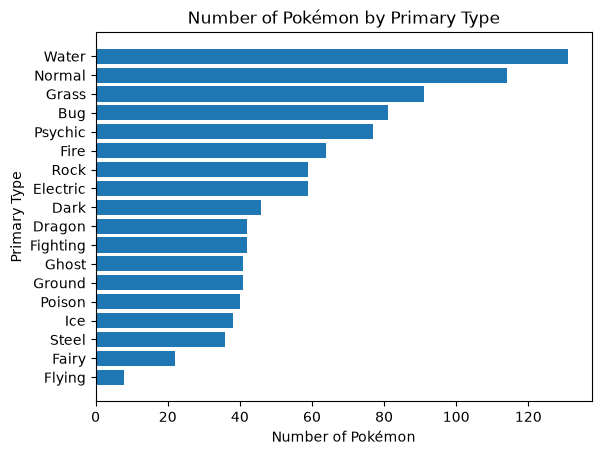

In [14]:
type_count = df['Type 1'].value_counts(ascending=True)

plt.barh(type_count.index,
         type_count.values)

plt.title("Number of Pokémon by Primary Type")

plt.xlabel("Number of Pokémon")
plt.ylabel("Primary Type")

plt.show()

### Interpretation

The graph compares the frequency of different Pokémon types, showing that some types are significantly more common than others.
# Conclusion

This notebook demonstrates how **Pandas** can be used for data cleaning and preprocessing and how **Matplotlib** can be used to create meaningful visualizations. Different chart types, including line graphs, bar graphs, histograms, pie charts, scatter plots, and heatmaps, were used to analyze the Netflix and Pokémon datasets. These visualizations provide valuable insights into content distribution, release trends, Pokémon characteristics, and relationships among different numerical attributes.